In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc
import glob

large_data_dir = gf_utils.large_data_dir
matplotlib.rcParams['pdf.fonttype'] = 42

from matplotlib.colors import LinearSegmentedColormap


In [2]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')
adata = adata[adata.obs['cell_type'] != 'Monocyte/Platelet doublet (non-HSPC)']
adata.obs.loc[(adata.obs['cell_type'] == 'Classical monocyte 2 (non-HSPC)'),'cell_type'] = 'Classical monocyte (non-HSPC)'

In [3]:
UMI_counts = pd.read_csv('../output/MPN_UMIs_per_cell.csv', index_col=0)
UMI_counts = UMI_counts.reindex(adata.obs_names)

UMI_counts['n_UMIs'] = UMI_counts['n_UMIs'].fillna(0).astype(int)
UMI_counts['n_sites_genotyped'] = UMI_counts['n_sites_genotyped'].fillna(0).astype(int)

adata.obs['n_targets_genotyped'] = UMI_counts['n_sites_genotyped']
adata.obs['log2_n_targets_genotyped'] = np.log2(adata.obs['n_targets_genotyped'])

/tmp/ipykernel_109526/1251647219.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_targets_genotyped'] = UMI_counts['n_sites_genotyped']
/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
### load in GoT counts per cell

CALR = pd.read_csv('../data/GSM3309842_MF05.CALR.txt', sep='\t', index_col=0)
NFE2 = pd.read_csv('../data/GSM3309843_MF05.NFE2.txt', sep='\t', index_col=0)
SF3B1 = pd.read_csv('../data/GSM3309844_MF05.SF3B1.txt', sep='\t', index_col=0)

got_data = CALR.merge(NFE2, left_index=True, right_index=True, suffixes=('_CALR', '_NFE2'), how='outer').merge(SF3B1, left_index=True, right_index=True, how='outer')
got_data = got_data.rename(columns={'num.WT.call':'num.WT.call_SF3B1', 'num.MUT.call':'num.MUT.call_SF3B1'})

# Add additional rows to bring length of merged to 8475 (total number of cells, from Fig. 5 of Nam et al)
additional_rows_needed = 8475 - len(got_data)
if additional_rows_needed > 0:
    # Create dummy rows with NaN values
    dummy_index = [f'DUMMY_{i:04d}' for i in range(additional_rows_needed)]
    dummy_data = pd.DataFrame(index=dummy_index, columns=got_data.columns)
    got_data = pd.concat([got_data, dummy_data])

/tmp/ipykernel_109526/3355233079.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  got_data = pd.concat([got_data, dummy_data])


In [5]:
### load in multi-GoT counts per cell

multi_got_files = glob.glob('../data/GSM889722*.csv')
multi_got_dfs = [pd.read_csv(f, index_col=0) for f in sorted(multi_got_files)]
multi_got_data = pd.concat(multi_got_dfs, axis=1)

### find the most targets that are captured in a single cell
multi_got_max = (multi_got_data.isin(['WT','MUT'])).sum(axis=1).max()

print(len(multi_got_data)) ## get cell count

52722


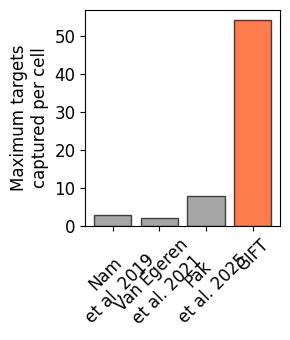

In [6]:
MPN_count = adata.obs['n_targets_genotyped'].max()
van_egeren_count = 2 ## JAK2 and TET2; cell count = 45007 from figure 1
nam_count = got_data.loc[:,got_data.columns.str.contains('WT')].notna().sum(axis=1).max()

# Combine all data with labels
data = {
    'Nam et al. 2019': nam_count,
    'Van Egeren et al. 2021': van_egeren_count,
    'Pak et al. 2025' : multi_got_max,
    'GIFT': MPN_count
}

vals = [nam_count, van_egeren_count, multi_got_max, MPN_count]

# Create the plot
fig, ax = plt.subplots(figsize=(3,3.5))

# Create bar plot with error bars
x_labels = ['Nam\net al. 2019', 'Van Egeren\net al. 2021', 'Pak\net al. 2025', 'GIFT']
x_pos = np.arange(len(x_labels))

bars = ax.bar(x_pos, vals, capsize=5, alpha=0.7, 
              color=['grey', 'grey', 'grey', 'orangered'],edgecolor='black')

ax.set_ylabel('Maximum targets\ncaptured per cell', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='center', size=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()

In [7]:
# Define gradient stops
colors = ["tab:blue", "tab:green", "tab:pink", "tab:red"]
cmap = LinearSegmentedColormap.from_list("blue_green_pink", colors)

712664


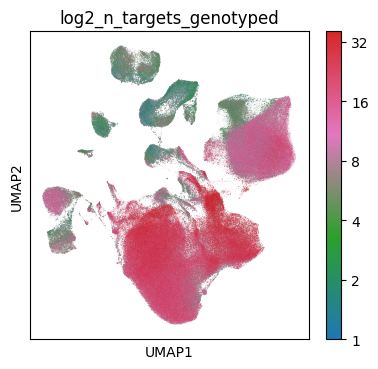

In [8]:
vmax = adata[adata.obs['n_targets_genotyped'] > 0].obs['log2_n_targets_genotyped'].quantile(0.99)
vmin = adata[adata.obs['n_targets_genotyped'] > 0].obs['log2_n_targets_genotyped'].quantile(0.01)

print(len(adata))
fig,ax = plt.subplots(figsize=(4.5,4))
sc.pl.umap(adata[adata.obs['n_targets_genotyped'] == 0], color = 'n_targets_genotyped', cmap='Greys', show=False, ax=ax)
# Remove the colorbar
ax.collections[-1].colorbar.remove()

sc.pl.umap(adata[adata.obs['n_targets_genotyped'] > 0], color = 'log2_n_targets_genotyped', cmap = cmap, vmax=vmax, vmin=vmin, show=False, ax=ax)
# Remove the colorbar
ax.collections[-1].colorbar.remove()

cbar = plt.colorbar(ax.collections[-1], ax=ax)
cbar.set_ticks([np.log2(1), np.log2(2), np.log2(4), np.log2(8), np.log2(16), np.log2(32)])
cbar.set_ticklabels(['1', '2', '4', '8', '16', '32'])

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/MPN_n_targets_genotyped_UMAP.pdf', bbox_inches = 'tight', dpi=300)

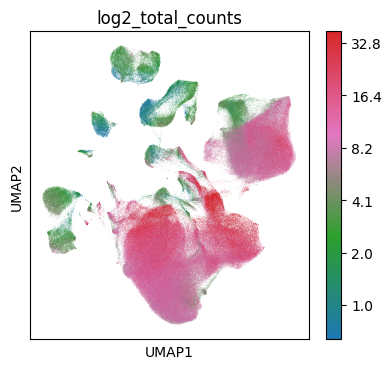

In [9]:
adata.obs['log2_total_counts'] = np.log2(adata.obs['total_counts'])
vmax = adata.obs['log2_total_counts'].quantile(0.99)
vmin = adata.obs['log2_total_counts'].quantile(0.01)

fig,ax = plt.subplots(figsize=(4.5,4))
sc.pl.umap(adata, color = 'log2_total_counts', cmap = cmap, vmax=vmax, vmin=vmin, show=False, ax=ax)

# Remove the original colorbar
plt.gca().collections[0].colorbar.remove()

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_ticks([10, 11, 12, 13, 14, 15])
cbar.set_ticklabels([str(np.round((2**i)/1000,1)) for i in range(10, 16)])

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/MPN_total_counts_UMAP.pdf', bbox_inches='tight', dpi=300)

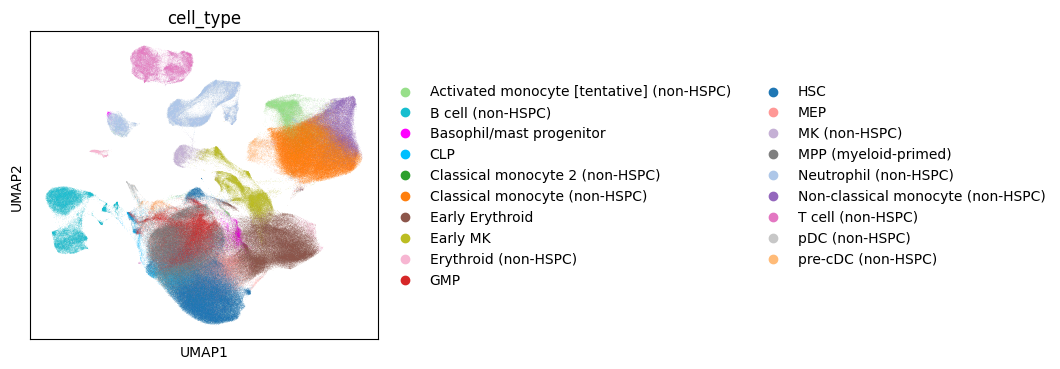

In [10]:
fig,ax = plt.subplots(figsize=(4.5,4))
sc.pl.umap(adata, color = 'cell_type',show=False, ax=ax)

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/MPN_cell_type_UMAP.pdf', bbox_inches='tight', dpi=300)